<a href="https://colab.research.google.com/github/kilianodonell-cmd/Q3_Durban/blob/main/Field_Map.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:

# Mount Google Drive (only in Colab)
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

print("Setup complete.")

Mounted at /content/drive
Setup complete.


In [2]:
import os, json, numpy as np
import geopandas as gpd
import rasterio
from rasterio.warp import reproject, Resampling, calculate_default_transform
import folium
from folium import LayerControl
from PIL import Image
import base64, io
import matplotlib.pyplot as plt
import pandas as pd


In [11]:
# ============================================================
# CELL 1 — Setup
# Field Map — Housing Suitability
# Mzinyati Stream Catchment, eThekwini Municipality
# ============================================================

# Load config (created by MCA notebook CELL 2)
CONFIG_PATH = '/content/drive/MyDrive/Durban/outputs/field_map_config.json'

with open(CONFIG_PATH) as f:
    config = json.load(f)

OUTPUT_ROOT    = config['OUTPUT_ROOT']
TARGET_CRS     = config['TARGET_CRS']
SCENARIOS      = config['SCENARIOS']
SUIT_COLORS    = config['SUIT_COLORS']
SUIT_LABELS    = config['SUIT_LABELS']
AOI_FIELD      = config['AOI_FIELD']
AOI_VALUE      = config['AOI_VALUE']
CATCHMENTS_PATH = config['CATCHMENTS_PATH']

RASTERS_DIR    = os.path.join(OUTPUT_ROOT, 'rasters')
BUILDINGS_PATH = os.path.join(OUTPUT_ROOT, 'outputs', 'at_risk_buildings.gpkg')
CLIPPED_DIR    = os.path.join(OUTPUT_ROOT, 'clipped')

print("=" * 60)
print("FIELD MAP SETUP")
print("=" * 60)
print(f"  Output root: {OUTPUT_ROOT}")
print(f"  Scenarios:   {list(SCENARIOS.keys())}")

# Check that required files exist
print("\n  Checking files...")
missing = []

for scenario in SCENARIOS:
    raster_path = os.path.join(RASTERS_DIR, f"suitability_{scenario}.tif")
    if os.path.exists(raster_path):
        print(f"    ✓ suitability_{scenario}.tif")
    else:
        print(f"    ✗ suitability_{scenario}.tif MISSING")
        missing.append(raster_path)

constraint_path = os.path.join(RASTERS_DIR, 'constraint_mask.tif')
if os.path.exists(constraint_path):
    print(f"    ✓ constraint_mask.tif")
else:
    print(f"    ✗ constraint_mask.tif MISSING")
    missing.append(constraint_path)

if os.path.exists(BUILDINGS_PATH):
    print(f"    ✓ at_risk_buildings.gpkg")
else:
    print(f"    ✗ at_risk_buildings.gpkg MISSING")
    missing.append(BUILDINGS_PATH)

if missing:
    print(f"\n  ⚠️ WARNING: {len(missing)} files missing. Run MCA notebook first.")
else:
    print(f"\n  ✓ All files ready. Proceed to CELL 2.")

print("=" * 60)

FIELD MAP SETUP
  Output root: /content/drive/MyDrive/Durban/outputs
  Scenarios:   ['hazard_focused', 'balanced', 'infrastructure_focused']

  Checking files...
    ✓ suitability_hazard_focused.tif
    ✓ suitability_balanced.tif
    ✓ suitability_infrastructure_focused.tif
    ✓ constraint_mask.tif
    ✓ at_risk_buildings.gpkg

  ✓ All files ready. Proceed to CELL 2.


In [15]:
# ============================================================
# CELL 2 — Load core data for field map
# ============================================================

import json
import os
import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
import matplotlib.pyplot as plt

print("=" * 60)
print("CELL 2 — LOAD CORE DATA")
print("=" * 60)

# ------------------------------------------------------------
# 1. Load catchments / AOI
# ------------------------------------------------------------
catchments = gpd.read_file(CATCHMENTS_PATH).to_crs(TARGET_CRS)

if AOI_FIELD not in catchments.columns:
    raise ValueError(
        f"AOI field '{AOI_FIELD}' not found in catchments layer.\n"
        f"Available fields: {list(catchments.columns)}"
    )

aoi = catchments[catchments[AOI_FIELD] == AOI_VALUE].copy()

if aoi.empty:
    raise ValueError(
        f"No AOI found where {AOI_FIELD} == {AOI_VALUE}"
    )

print(f"✓ AOI loaded: {len(aoi)} feature(s)")

# ------------------------------------------------------------
# 2. Load at-risk buildings
# ------------------------------------------------------------
buildings = gpd.read_file(BUILDINGS_PATH).to_crs(TARGET_CRS)

print(f"✓ At-risk buildings loaded: {len(buildings):,}")

# ------------------------------------------------------------
# 3. Basic checks
# ------------------------------------------------------------
required_base_cols = ["in_constraint", "geometry"]
missing_base = [c for c in required_base_cols if c not in buildings.columns]

if missing_base:
    raise ValueError(
        f"Missing required columns in at_risk_buildings.gpkg: {missing_base}"
    )

print(f"✓ Required base columns present: {required_base_cols}")

# ------------------------------------------------------------
# 4. Detect score columns automatically
# ------------------------------------------------------------
raw_score_cols = [c for c in buildings.columns if c.startswith("raw_score_")]
display_score_cols = [c for c in buildings.columns if c.startswith("display_score_")]

print("\nAvailable raw score columns:")
for c in raw_score_cols:
    print(f"  - {c}")

print("\nAvailable display score columns:")
for c in display_score_cols:
    print(f"  - {c}")

if len(display_score_cols) == 0:
    raise ValueError(
        "No display_score_* columns found in at_risk_buildings.gpkg.\n"
        "Re-run CELL 15 in the MCA notebook and save again."
    )

# ------------------------------------------------------------
# 5. Choose default scenario
# ------------------------------------------------------------
DEFAULT_SCENARIO = "hazard_focused"

display_col = f"display_score_{DEFAULT_SCENARIO}"
raw_col = f"raw_score_{DEFAULT_SCENARIO}"

if display_col not in buildings.columns:
    raise ValueError(
        f"Default display column not found: {display_col}\n"
        f"Available display columns: {display_score_cols}"
    )

if raw_col not in buildings.columns:
    print(f"⚠ Raw column not found: {raw_col}")
    raw_col = None
else:
    print(f"\n✓ Default scenario: {DEFAULT_SCENARIO}")
    print(f"  Raw score column:     {raw_col}")
    print(f"  Display score column: {display_col}")

# ------------------------------------------------------------
# 6. Add plotting color column using MCA colors
# SUIT_COLORS is a list ordered for classes 1..5
# ------------------------------------------------------------
buildings["plot_score"] = buildings[display_col].astype(int)

def score_to_color(score):
    if score in [1, 2, 3, 4, 5]:
        return SUIT_COLORS[score - 1]
    return "#9e9e9e"   # fallback grey for unexpected values

buildings["plot_color"] = buildings["plot_score"].apply(score_to_color)

# ------------------------------------------------------------
# 7. Quick summary
# ------------------------------------------------------------
print("\nDisplay score distribution:")
print(buildings[display_col].value_counts(dropna=False).sort_index())

print("\nBuildings in constraints:")
print(buildings["in_constraint"].sum())

if raw_col is not None:
    print("\nRaw score distribution for constrained buildings:")
    print(
        buildings.loc[
            buildings["in_constraint"] == True,
            raw_col
        ].value_counts(dropna=False).sort_index()
    )

print("=" * 60)
print("CELL 2 complete. Proceed to CELL 3.")
print("=" * 60)

CELL 2 — LOAD CORE DATA
✓ AOI loaded: 2 feature(s)
✓ At-risk buildings loaded: 22,196
✓ Required base columns present: ['in_constraint', 'geometry']

Available raw score columns:
  - raw_score_hazard_focused
  - raw_score_balanced
  - raw_score_infrastructure_focused

Available display score columns:
  - display_score_hazard_focused
  - display_score_balanced
  - display_score_infrastructure_focused

✓ Default scenario: hazard_focused
  Raw score column:     raw_score_hazard_focused
  Display score column: display_score_hazard_focused

Display score distribution:
display_score_hazard_focused
-1       1
 1     121
 2    4620
 3    9475
 4    3649
 5    4330
Name: count, dtype: int64

Buildings in constraints:
4268

Raw score distribution for constrained buildings:
raw_score_hazard_focused
-1     196
 1     114
 2     726
 3    1333
 4    1823
 5      76
Name: count, dtype: int64
CELL 2 complete. Proceed to CELL 3.


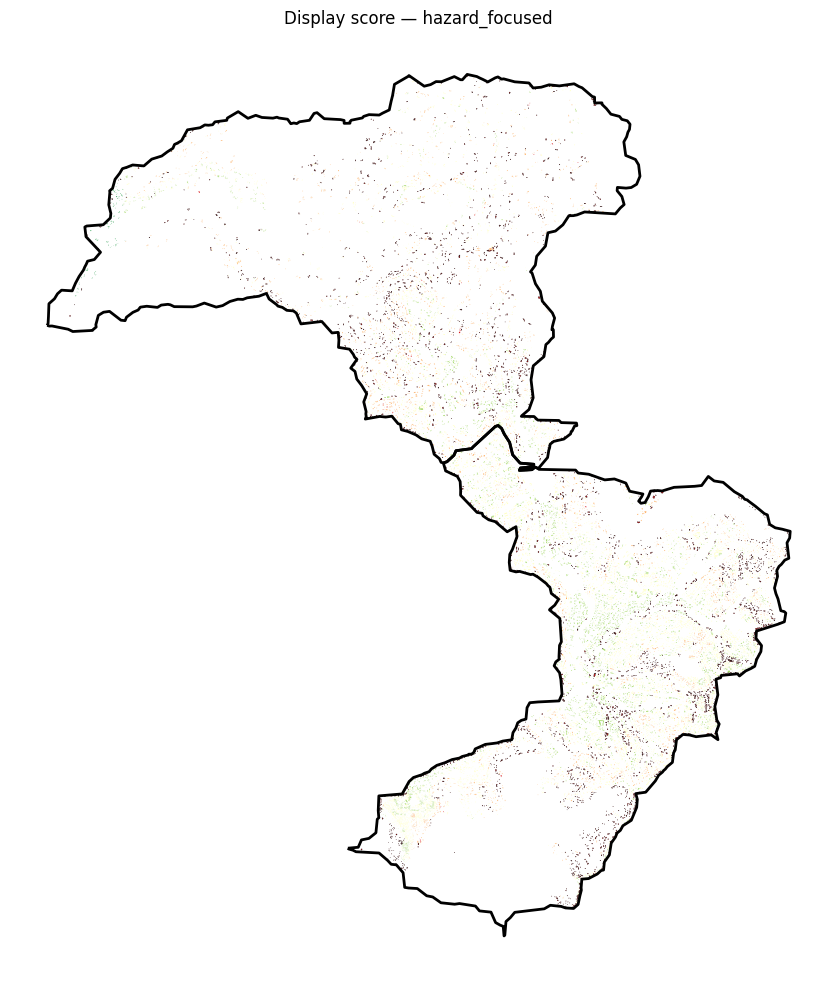

In [24]:
# ============================================================
# CELL 3 — Quick overview map with correct display scores
# ============================================================

# choose scenario
DEFAULT_SCENARIO = "hazard_focused"
display_col = f"display_score_{DEFAULT_SCENARIO}"

# make sure score is integer
buildings["plot_score"] = buildings[display_col].astype(int)

# map suitability class to MCA colors
def score_to_color(score):
    if score in [1, 2, 3, 4, 5]:
        return SUIT_COLORS[score - 1]   # list index 0..4
    elif score == -1:
        return "#9e9e9e"                # grey for no data
    return "#000000"                    # fallback

buildings["plot_color"] = buildings["plot_score"].apply(score_to_color)

# plot
fig, ax = plt.subplots(figsize=(10, 10))

# AOI boundary
aoi.boundary.plot(
    ax=ax,
    color="black",
    linewidth=2
)

# buildings with correct display colors
buildings.plot(
    ax=ax,
    color=buildings["plot_color"],
    markersize=4,
    edgecolor="none"
)

# optional: outline constrained buildings
buildings.loc[buildings["in_constraint"] == True].plot(
    ax=ax,
    facecolor="none",
    edgecolor="black",
    linewidth=0.2
)

ax.set_title(f"Display score — {DEFAULT_SCENARIO}")
ax.set_axis_off()

plt.tight_layout()
plt.show()